In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.transforms as T
from torch.nn.modules.loss import BCEWithLogitsLoss
from torch.utils.data import Dataset
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as window_transform
from rasterio.merge import merge, copy_sum
from rasterio.plot import show
import numpy as np
import matplotlib
import os
import glob
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("[INFO] training using {} ...".format(DEVICE))

[INFO] training using cpu ...


In [2]:
# Definisi arsitektur U-Net
class UNet(nn.Module):
    def __init__(self, in_channels=7, out_channels=14):  # out_channels=1 untuk biner
        super(UNet, self).__init__()
        
        # Encoder
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)
        
        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)
        
        # Decoder
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)
        
        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)
        
        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)
        
        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)
        
        # Output layer dengan satu channel (untuk output biner)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(F.max_pool2d(enc1, 2))
        enc3 = self.encoder3(F.max_pool2d(enc2, 2))
        enc4 = self.encoder4(F.max_pool2d(enc3, 2))
        
        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool2d(enc4, 2))
        
        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        
        # Final output layer
        return self.final_conv(dec1)

In [ ]:
# Fungsi split image agar sesuai dimensi input sebelum prediksi
def split(image_path, window_size, stride, outfolder):
    # Membuka file citra
    with rasterio.open(image_path) as src:
        width, height = src.width, src.height  # Dimensi citra
        out_path = outfolder

        # Iterasi melalui koordinat x dan y
        for y in range(0, height - window_size + 1, stride):  # Menangani kasus sisa piksel di tepi
            for x in range(0, width - window_size + 1, stride):
                # Membuat jendela (window)
                window2 = Window(x, y, window_size, window_size)
                transform2 = window_transform(window2, src.transform)

                # Membaca data citra dalam window
                image_data = src.read(indexes=[1, 2, 3, 4, 5, 6, 7], window=window2) # Pilih band 1-7 saja

                # Debugging untuk memeriksa dimensi data yang dipotong
                print(f"Processed crop at x: {x}, y: {y}, shape: {image_data.shape}")

                # Memperbarui metadata
                out_meta = src.meta.copy()
                out_meta.update({
                    'driver': 'GTiff',
                    'width': window_size,
                    'height': window_size,
                    'count': 7,  # sesuaikan dengan band input training
                    'crs': src.crs,
                    'transform': transform2
                })

                # Menyimpan hasil potongan ke file baru
                crop_filename = f"crop_{y}_{x}.tif"
                crop_path = os.path.join(out_path, crop_filename)

                with rasterio.open(crop_path, 'w', **out_meta) as output:
                    output.write(image_data)

    print("Splitting completed.")

In [ ]:
# Path citra prediksi dan output penyimpan hasil split image
test_image = "D:\\Folu Net Sink 2030\\Citra_7band\\processed_2024-04-03_strip_7218109_composite.tif"
output_folder = "E:\\Folu Net Sink 2030\\Predict\\LULC detail\\Clip"

# Split image
split(test_image, 256, 256, output_folder)

list_split_image = glob.glob(os.path.join(output_folder, "*.tif"))

Processed crop at x: 0, y: 0, shape: (7, 256, 256)
Processed crop at x: 256, y: 0, shape: (7, 256, 256)
Processed crop at x: 512, y: 0, shape: (7, 256, 256)
Processed crop at x: 768, y: 0, shape: (7, 256, 256)
Processed crop at x: 1024, y: 0, shape: (7, 256, 256)
Processed crop at x: 1280, y: 0, shape: (7, 256, 256)
Processed crop at x: 1536, y: 0, shape: (7, 256, 256)
Processed crop at x: 1792, y: 0, shape: (7, 256, 256)
Processed crop at x: 2048, y: 0, shape: (7, 256, 256)
Processed crop at x: 2304, y: 0, shape: (7, 256, 256)
Processed crop at x: 2560, y: 0, shape: (7, 256, 256)
Processed crop at x: 2816, y: 0, shape: (7, 256, 256)
Processed crop at x: 3072, y: 0, shape: (7, 256, 256)
Processed crop at x: 3328, y: 0, shape: (7, 256, 256)
Processed crop at x: 3584, y: 0, shape: (7, 256, 256)
Processed crop at x: 3840, y: 0, shape: (7, 256, 256)
Processed crop at x: 4096, y: 0, shape: (7, 256, 256)
Processed crop at x: 4352, y: 0, shape: (7, 256, 256)
Processed crop at x: 4608, y: 0, s

In [6]:
# Tentukan perangkat (GPU atau CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Inisialisasi model
model = UNet().to(device)

# Muat state dictionary
state_dict = torch.load('E:\\Folu Net Sink 2030\\Script\\unet_model.pth', map_location=torch.device('cpu'))
model.load_state_dict(state_dict)  # Jangan gunakan `model =`

# Ubah model ke mode evaluasi
model.eval()

UNet(
  (encoder1): Sequential(
    (0): Conv2d(7, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (encoder3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (encoder4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Con

In [ ]:
# Panggil data hasil split image
split_folder = "E:\\Folu Net Sink 2030\\Predict\\LULC detail\\Clip"
split_image = glob.glob(os.path.join(split_folder, "*.tif"))
print(len(split_image))

#Fungsi membuat folder
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

# output folder (buat dulu sebelum dirunning)
outfolder = 'E:\\Folu Net Sink 2030\\Predict\\LULC detail\\Clip\\hasil_1'
create_dir(outfolder)

1044


In [ ]:
# Loop untuk prediksi dengan model UNet
for i, obj in enumerate(split_image):
    t1 = obj
    filename = os.path.basename(t1)
    print(f"Processing: {filename}")

    # Buka data menggunakan Rasterio
    t2 = rasterio.open(t1)
    t3 = t2.read()  # Membaca data dalam bentuk (C, H, W)
    t3 = np.expand_dims(t3, axis=0)  # Ubah menjadi bentuk (BatchSize, C, H, W)
    print(f"Input shape: {t3.shape}")

    # Normalisasi data ke skala 0-1
    t3 = t3 / 65535.0

    # Konversi ke tipe float32 dan tensor PyTorch
    t3_flts = t3.astype(np.float32)
    t3_tensor = torch.from_numpy(t3_flts).to(device)

    # Klasifikasi dengan model UNet
    with torch.no_grad():  # Nonaktifkan gradient computation untuk prediksi
        t3_pred = model(t3_tensor)
    
    # Gunakan softmax untuk menghasilkan probabilitas untuk setiap kelas
    t3_pred = torch.softmax(t3_pred, dim=1)  # Softmax di sepanjang channel (dim=1) #Softmax untuk multiclass
    
    # Ambil kelas dengan probabilitas tertinggi
    t3_class = torch.argmax(t3_pred, dim=1).cpu().numpy()  # Ambil indeks kelas dengan nilai maksimum
    t3_class = t3_class[0]  # (BatchSize, H, W) -> (H, W)
    print(f"Output shape: {t3_class.shape}")

    # Ubah hasil prediksi menjadi raster
    out_meta = t2.meta.copy()
    out_meta.update({
        'driver': 'GTiff',
        'height': t3_class.shape[0],
        'width': t3_class.shape[1],
        'count': 1,
        'dtype': 'uint8',  # Simpan hasil prediksi sebagai tipe uint8
        'crs': t2.crs,
        'transform': t2.transform
    })
    out_meta.pop("nodata", None)  # Hapus atribut nodata jika ada
    out_path = os.path.join(outfolder, f'hasil_unet_{filename}')
    with rasterio.open(out_path, 'w', **out_meta) as dest:
        dest.write(t3_class.astype(np.uint8), 1)

    print(f"Saved: {out_path}")


Processing: crop_0_0.tif
Input shape: (1, 7, 256, 256)
Output shape: (256, 256)
Saved: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\hasil_unet_crop_0_0.tif
Processing: crop_0_1024.tif
Input shape: (1, 7, 256, 256)
Output shape: (256, 256)
Saved: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\hasil_unet_crop_0_1024.tif
Processing: crop_0_1280.tif
Input shape: (1, 7, 256, 256)
Output shape: (256, 256)
Saved: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\hasil_unet_crop_0_1280.tif
Processing: crop_0_1536.tif
Input shape: (1, 7, 256, 256)
Output shape: (256, 256)
Saved: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\hasil_unet_crop_0_1536.tif
Processing: crop_0_1792.tif
Input shape: (1, 7, 256, 256)
Output shape: (256, 256)
Saved: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\hasil_unet_crop_0_1792.tif
Processing: crop_0_2048.tif
Input shape: (1, 7, 256, 256)
Output shape: (256, 256)
Saved: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\h

In [ ]:
#mosaic hasil prediksi

list_hasil = glob.glob(os.path.join(outfolder, "*tif"))
print(len(list_hasil))

# Open the files as datasets
src_files_to_mosaic = []
for fp in list_hasil:
    src = rasterio.open(fp)
    src_files_to_mosaic.append(src)

# Merge the datasets
mosaic, out_trans = merge(src_files_to_mosaic, method = copy_sum)

# Update the metadata with the new dimensions, transform, and crs
out_meta = src.meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "dtype": mosaic.dtype
})

# Save the merged result as a new GeoTIFF file
output_path = os.path.join(outfolder, "2024_IKN_unet.tif")
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(mosaic)

print(f"Merged file saved at: {output_path}")

# Close the datasets
for src in src_files_to_mosaic:
    src.close()


1044
Merged file saved at: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\2024_IKN_unet.tif


## Reklasifikasi

In [14]:
# Mapping antara kelas prediksi (0-13) dengan kelas asli
class_mapping = {
    0: 11,  # Kelas 0 menjadi 11
    1: 13,  # Kelas 1 menjadi 13
    2: 15,  # Kelas 2 menjadi 15
    3: 21,  # Kelas 3 menjadi 21
    4: 22,  # Kelas 4 menjadi 22
    5: 33,  # Kelas 5 menjadi 33
    6: 34,  # Kelas 6 menjadi 34
    7: 41,  # Kelas 7 menjadi 41
    8: 54,  # Kelas 8 menjadi 54
    9: 60,  # Kelas 9 menjadi 60
    10: 71, # Kelas 10 menjadi 71
    11: 72, # Kelas 11 menjadi 72
    12: 81, # Kelas 12 menjadi 81
    13: 82  # Kelas 13 menjadi 82
}

# Fungsi untuk mereklasifikasi hasil prediksi
def reclassify(prediction):
    # Membuat salinan dari hasil prediksi
    reclassified = np.copy(prediction)

    # Melakukan reklassifikasi menggunakan mapping
    for pred_class, new_class in class_mapping.items():
        reclassified[prediction == pred_class] = new_class

    return reclassified

# Contoh penggunaan pada hasil prediksi
mosaic_reclassified = reclassify(mosaic)

# Update the metadata with the new dimensions, transform, and crs
out_meta_reclasss = src.meta.copy()
out_meta_reclasss.update({
    "driver": "GTiff",
    "height": mosaic_reclassified.shape[1],
    "width": mosaic_reclassified.shape[2],
    "transform": out_trans,
    "dtype": mosaic_reclassified.dtype
})

# Save the merged result as a new GeoTIFF file
output_path_reclass = os.path.join(outfolder, "2024_IKN_unet_reclass.tif")
with rasterio.open(output_path_reclass, "w", **out_meta_reclasss) as dest:
    dest.write(mosaic_reclassified)

print(f"Merged reclassified file saved at: {output_path_reclass}")


Merged reclassified file saved at: E:\Folu Net Sink 2030\Predict\LULC detail\Clip\hasil_1\2024_IKN_unet_reclass.tif


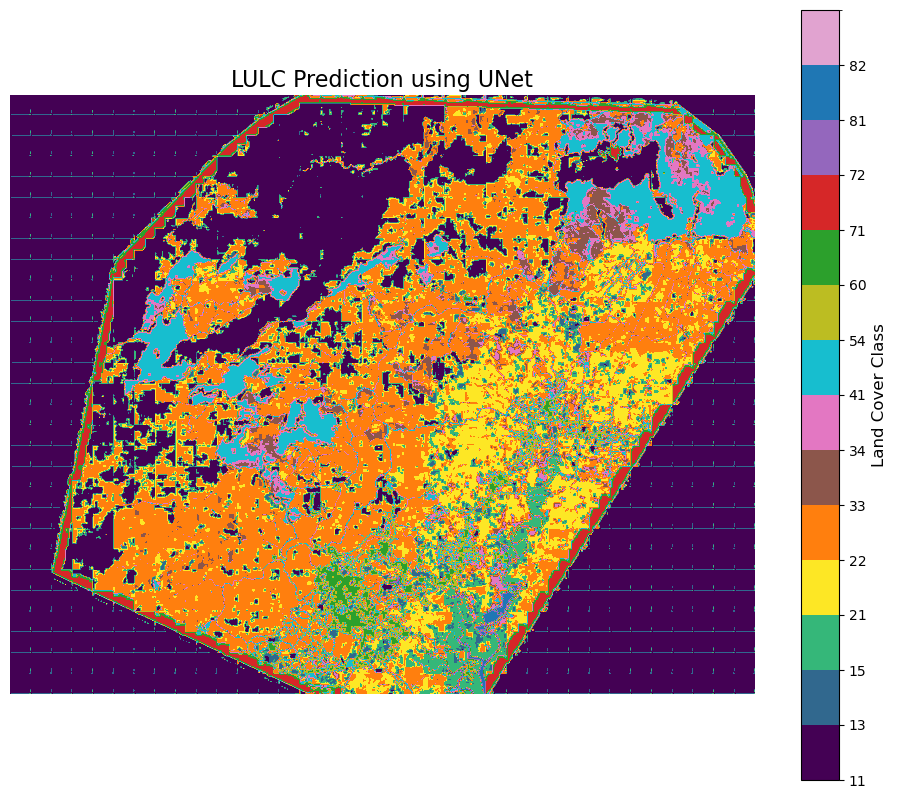

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
# Definisikan kelas dan warna untuk setiap kelas
classes = [11, 13, 15, 21, 22, 33, 34, 41, 54, 60, 71, 72, 81, 82]
colors = [
    "#440154", "#31688e", "#35b779", "#fde725", "#ff7f0e", "#8c564b", 
    "#e377c2", "#17becf", "#bcbd22", "#2ca02c", "#d62728", "#9467bd", 
    "#1f77b4", "#e1a3d0"
]
cmap = ListedColormap(colors)

# Membuat batas kelas untuk legend
bounds = classes + [max(classes) + 1]  # Tambahkan batas atas
norm = BoundaryNorm(bounds, len(classes))

# Pastikan data mosaic menjadi 2D
mosaic_2d = mosaic_reclassified[0, :, :]  # Ambil channel pertama (dimensi 1 dihilangkan)

# Visualisasi hasil prediksi
def visualize_prediction(title, prediction, cmap, classes, norm):
    plt.figure(figsize=(12, 10))
    plt.title(title, fontsize=16)
    im = plt.imshow(prediction, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=classes)
    cbar.ax.set_yticklabels(classes, fontsize=10)  # Menampilkan label sesuai kelas
    cbar.set_label("Land Cover Class", fontsize=12)
    plt.axis("off")
    plt.show()

visualize_prediction("LULC Prediction using UNet", mosaic_2d, cmap, classes, norm)
